In [90]:
import pandas as pd 
import numpy as np 
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler , OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import confusion_matrix ,classification_report, accuracy_score, precision_score,recall_score,f1_score

In [91]:
df=pd.read_csv("return_fraud.csv")
df.head()

,user_id,total_orders,total_returns,return_ratio,order_value,account_age_dats,acc_creation_date,days_since_last_return,return_last_7_days,product_category,return_reason,is_high_value,risk_score,is_fraud
0,0,90,0,0.0,661,2025-03-13 14:46:15.855404,396,82,2,home,not_needed,0,0.000000,0
1,1,83,0,0.0,1413,2026-04-12 14:46:15.855732,1,75,1,Toys_&_kids,damaged,0,0.286389,0
2,2,4,0,0.0,1941,2025-12-30 14:46:15.855924,104,61,2,electronics,wrong_item,0,0.000000,0
3,3,17,0,0.0,1776,2026-04-08 14:46:15.856074,5,8,1,fitness_&_sports,not_needed,0,0.336847,0
4,4,20,0,0.0,2007,2026-04-02 14:46:15.856308,11,49,3,fashion,size_issue,0,0.236971,0


In [92]:
df=df.drop(columns=["account_age_dats", "user_id"])

In [93]:
df=df.rename(columns={
    "acc_creation_date":"acc_age_days"
})

In [94]:
df.head()

,total_orders,total_returns,return_ratio,order_value,acc_age_days,days_since_last_return,return_last_7_days,product_category,return_reason,is_high_value,risk_score,is_fraud
0,90,0,0.0,661,396,82,2,home,not_needed,0,0.000000,0
1,83,0,0.0,1413,1,75,1,Toys_&_kids,damaged,0,0.286389,0
2,4,0,0.0,1941,104,61,2,electronics,wrong_item,0,0.000000,0
3,17,0,0.0,1776,5,8,1,fitness_&_sports,not_needed,0,0.336847,0
4,20,0,0.0,2007,11,49,3,fashion,size_issue,0,0.236971,0


In [95]:
X=df.drop(columns=["is_fraud"])
y=df["is_fraud"]

In [96]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

In [97]:
cat_cols=X_train.select_dtypes(include=["object", "category"]).columns
num_cols=X_train.select_dtypes(include=["int64", "float64"]).columns

skewness=X_train[num_cols].skew() 

skew_num_cols=skewness[abs(skewness)>1].index

normal_num_cols=skewness[abs(skewness)<=0.5].index





C:\Users\BIMAN\AppData\Local\Temp\ipykernel_5976\2752819284.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=X_train.select_dtypes(include=["object", "category"]).columns


In [98]:
preprocessor=ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols), 
        ("normal", StandardScaler(), normal_num_cols) ,
        ("skewed", PowerTransformer(method='yeo-johnson'), skew_num_cols)
    ]
)

## Logistic Regression

In [99]:
pipe=Pipeline([

    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
]
    
)

In [100]:
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('normal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [101]:
y_prob_lr=pipe.predict_proba(X_test)[:,1]

In [102]:
y_pred_lr = pipe.predict(X_test)

In [103]:
y_pred_lr=(y_prob_lr>0.3)

In [104]:
cm=confusion_matrix(y_test,y_pred_lr)

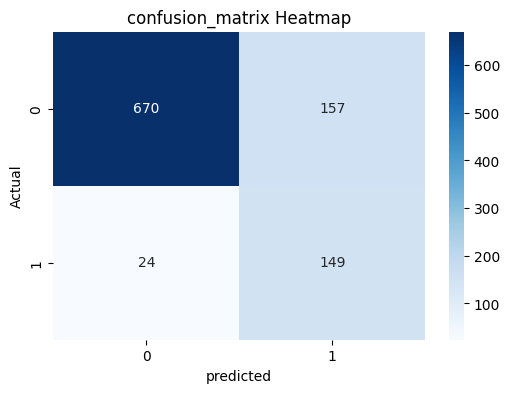

In [105]:
plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True, fmt='d', cmap="Blues")

plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("confusion_matrix Heatmap")
plt.show()

In [106]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      0.81      0.88       827
           1       0.49      0.86      0.62       173

    accuracy                           0.82      1000
   macro avg       0.73      0.84      0.75      1000
weighted avg       0.88      0.82      0.84      1000



## Random Forest classifier

In [107]:
model=Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ))
])

In [108]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('normal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [109]:
y_prob_rf=model.predict_proba(X_test)[:,1]

In [110]:
y_pred_rf=model.predict(X_test)

In [111]:
y_pred=(y_prob_rf>0.4)

In [112]:
cm=confusion_matrix(y_test,y_pred_rf)

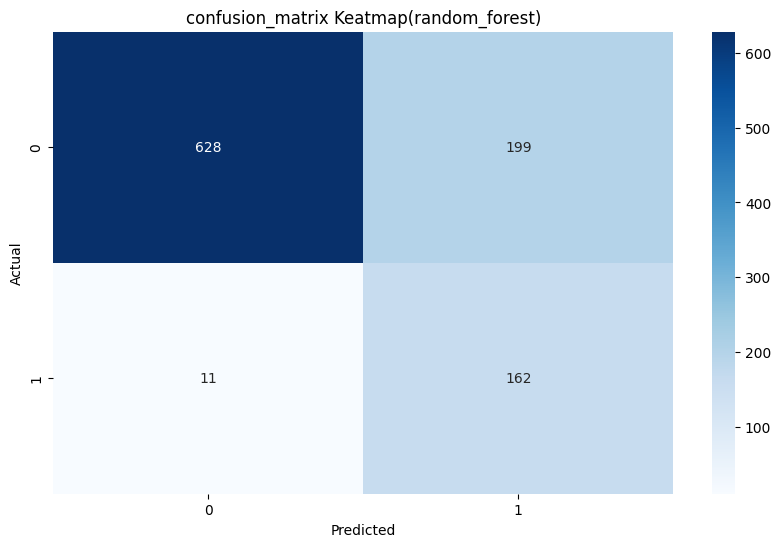

In [113]:
plt.figure(figsize=(10,6))

sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion_matrix Keatmap(random_forest)")
plt.show()

In [114]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.76      0.86       827
           1       0.45      0.94      0.61       173

    accuracy                           0.79      1000
   macro avg       0.72      0.85      0.73      1000
weighted avg       0.89      0.79      0.81      1000



## Comparision Of models

In [115]:
#Logistic Regression

lr_acc=accuracy_score(y_test,y_pred_lr)
lr_prec=precision_score(y_test,y_pred_lr)
lr_rec=recall_score(y_test,y_pred_lr) 
lr_f1=f1_score(y_test,y_pred_lr)


# Random Forest 

rf_acc=accuracy_score(y_test,y_pred_rf)
rf_prec=precision_score(y_test,y_pred_rf)
rf_rec=recall_score(y_test,y_pred_rf)
rf_f1=f1_score(y_test,y_pred_rf) 

In [116]:
comparision=pd.DataFrame({"Metric":["Accuracy", "Precision", "Recall", "F1_score"],
                          "Logistic_Regression":[lr_acc,lr_prec,lr_rec,lr_f1],
                          "Random_Forest":[rf_acc,rf_prec,rf_rec,rf_f1]})

comparision

,Metric,Logistic_Regression,Random_Forest
0,Accuracy,0.819000,0.790000
1,Precision,0.486928,0.448753
2,Recall,0.861272,0.936416
3,F1_score,0.622129,0.606742


In [117]:
comparision["Better Model"]=comparision[["Logistic_Regression", "Random_Forest"]].idxmax(axis=1)
comparision

,Metric,Logistic_Regression,Random_Forest,Better Model
0,Accuracy,0.819000,0.790000,Logistic_Regression
1,Precision,0.486928,0.448753,Logistic_Regression
2,Recall,0.861272,0.936416,Random_Forest
3,F1_score,0.622129,0.606742,Logistic_Regression


since this is a fraud detection problem rcall is more critical than precision. Random Forest has significantly higher recall(0.93), meaning is detects more fraud cases and reduces false negative. Therefore, I would choose Random Forest , While considering thresold tuning to improve precision.

In [118]:
import joblib

joblib.dump(model, "rf_model.pkl")

['rf_model.pkl']

In [ ]:
import pandas as pd

feature_names = model.named_steps['preprocessor'].get_feature_names_out()
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": model.named_steps['model'].feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importance)

AttributeError: 'Pipeline' object has no attribute 'named_steps_'